In [135]:
import torch
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification
from transformers.models.vit import modeling_vit
import inspect
import matplotlib.pyplot as plt
import os
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random

In [136]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [137]:


# loading a small pertrained visual Transformor and processor
model = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model)
model = ViTForImageClassification.from_pretrained(model, attn_implementation="eager")

model.eval()

model = model.to(DEVICE)
print(f'Using {DEVICE} device')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Using cpu device


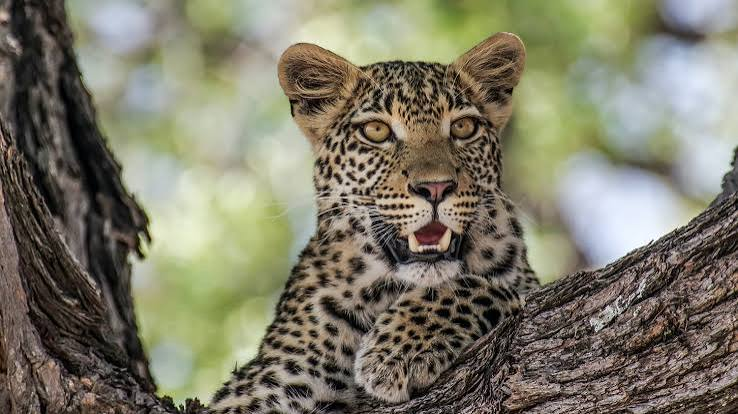

In [138]:
image_path = "/content/sample_data/images/leopard1.jpg"
image = Image.open(image_path)
display(image)



In [139]:
paths = [
    '/content/sample_data/images/leopard1.jpg',
    # '/images/leopard2.jpg',
    # '/images/dog1.jpg',
    # '/images/dog2.jpg',
    # '/images/dog3.jpg',
    # '/images/cat2.jpg',
    # '/images/cat3.jpg',
    # '/images/cat4.jpg',
]

images = [Image.open(path).convert("RGB") for path in paths]
inputs = processor(images=images, return_tensors="pt")
print(inputs.pixel_values.shape)

torch.Size([1, 3, 224, 224])


# Task 2.1 Run the images through the ViT model to obtain predicted class labels.

In [140]:
with torch.no_grad():
  outputs = model(**inputs)
  logits = outputs.logits

prob = logits.softmax(-1)
top5 = prob.topk(5, dim= -1)

In [141]:
for i, path in enumerate(paths):
  print(f"\n - {os.path.basename(path)}")

  for score, index in zip(top5.values[i], top5.indices[i]):
    label = model.config.id2label[index.item()]
    print(f"    {label:45s} {score.item(): .4f}")


 - leopard1.jpg
    leopard, Panthera pardus                       0.9900
    jaguar, panther, Panthera onca, Felis onca     0.0076
    cheetah, chetah, Acinonyx jubatus              0.0010
    snow leopard, ounce, Panthera uncia            0.0004
    lion, king of beasts, Panthera leo             0.0002


**- Record the top-1 prediction—the model’s guess for the object in the image and state whether the prediction seems reasonable.**

Model correctly assigned 99% probability to *Leopard* class, which is indeeed a very high confidence score. In fact all top five probabilities were assigned to the Cats family, depecting that the model was able to strongly learn the features majorly similar in large cats in genernal and not only that it was also able to nearly perfectly differentiate between the features of leopard like Rosetter spots, tear liner etc vs other cat like cheetahs in particular.




# Task 2.2: Visualizing Patch Attention

In [142]:
with torch.no_grad():
  outputs = model(**inputs, output_attentions=True, output_hidden_states=True)
  logits = outputs.logits

  print(len(outputs.attentions), outputs.attentions[0].shape)

12 torch.Size([1, 12, 197, 197])


tensor(0.) tensor(1.)


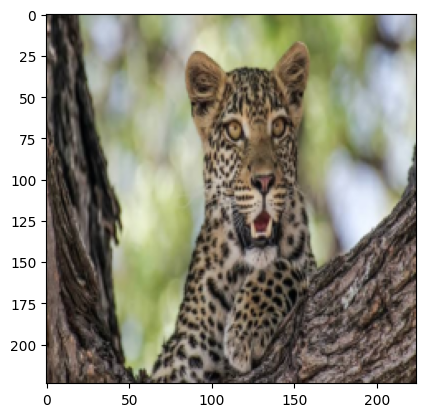

(224, 224, 3)


In [143]:
imgs = processor(images=images, return_tensors="pt", do_normalize=False)
img = imgs["pixel_values"][0]
print(img.min(), img.max())

img = img.permute(1, 2, 0)
img = img.cpu().numpy()

plt.imshow(img)
plt.show()

print(img.shape)

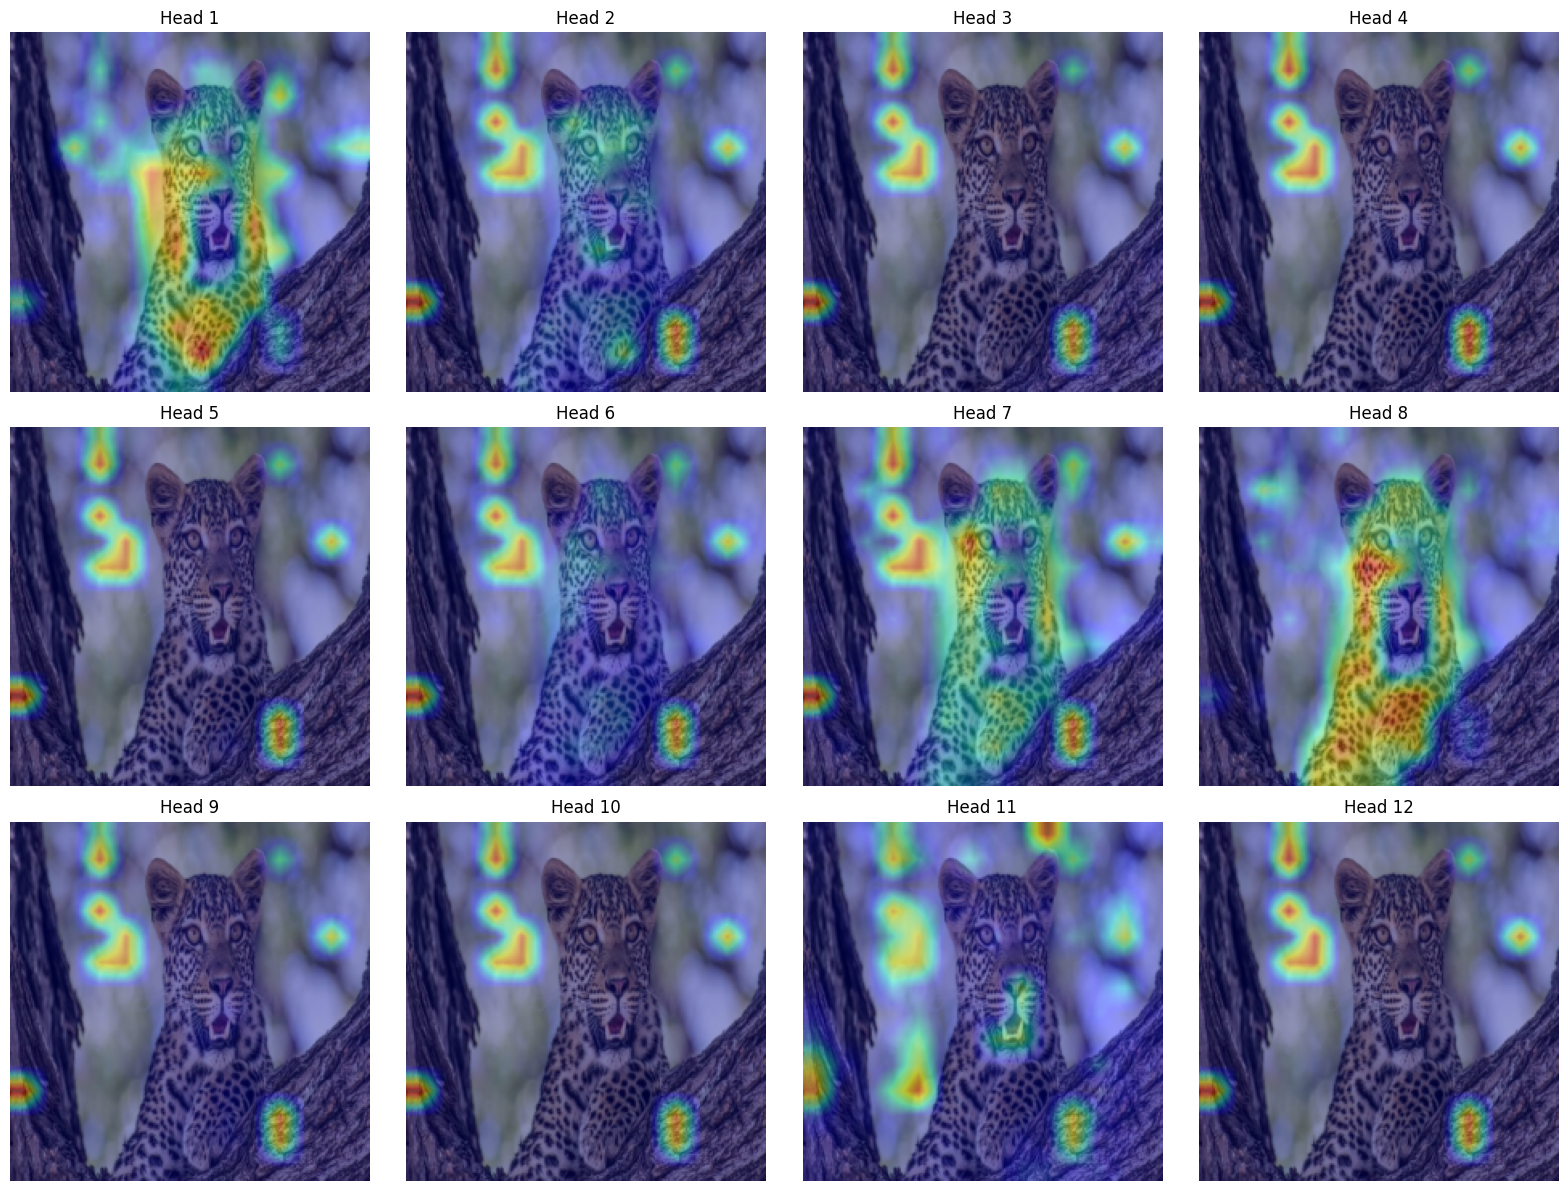

In [144]:
attention = outputs.attentions[-1][0]
heads = attention.shape[0] # 12, 197, 197

cls_atten_heads = attention[:, 0 , 1:]

fig, axes = plt.subplots(3, 4, figsize=(16,12))

for head in range(heads):
  cls_attn = cls_atten_heads[head]
  cls_attn = cls_attn.reshape(14, 14)
  cls_attn = ( cls_attn - cls_attn.min() ) / (cls_attn.max() - cls_attn.min() + 1e-8)

  cls_attn = F.interpolate(cls_attn.unsqueeze(0).unsqueeze(0),
                           size=img.shape[:2],
                           mode="bilinear",
                           align_corners=False).squeeze()

  heatmap = plt.cm.jet(cls_attn.detach().cpu().numpy())[:, :, :3]
  ovrlay = (0.6 * img + 0.4 * heatmap)
  ovrlay = np.clip(ovrlay, 0, 1)

  axes.flat[head].imshow(ovrlay)
  axes.flat[head].set_title(f"Head {head + 1}")
  axes.flat[head].axis("off")


plt.tight_layout()
plt.show()



# Task 2.3: Analyze the Attention Map

- Attention Map overlay observations

`google/vit-base-patch16-224 ` model receives  the input image of size 224 × 224 pixels and convert that into a grid of non-overlapping patches, where each patch has a size of 16 × 16 pixels. Therefore for a 224 x 224 image we get 196 patches arranged as a 14 x 14 grid.

Along with 196 input patches ViT introduces one additional CLS token, giving 197 tokens. so we have 196 patches plus the additional CLS token. Thus the final layer of ViT have N = 196 patches and a hidden dimension d = 768 given by:

$$\mathbf{H} = [\mathbf{h}_{\text{CLS}}, \mathbf{z}_1, \mathbf{z}_2, \dots, \mathbf{z}_N] \in \mathbb{R}^{(N+1) \times d}$$


where
- $\mathbf{h}_{\text{CLS}} = \mathbf{H}_{0, :} \in \mathbb{R}^d$ is the [CLS] token representation
- $\mathbf{z}_i = \mathbf{H}_{i, :} \in \mathbb{R}^d$ for $i \in \{1, \dots, N\}$ are the spatial patch tokens.


**CLS Token Pooling**:

$$\mathbf{f}_{\text{CLS}} = \mathbf{h}_{\text{CLS}} = \sum_{j=0}^{N} \mathbf{A}_{0, j} \mathbf{V}_j \in \mathbb{R}^d$$


where $\mathbf{A}_{0, j} = \text{softmax}\left(\frac{\mathbf{q}_{\text{CLS}} \mathbf{k}_j^\top}{\sqrt{d_k}}\right)$ represents the attention weights from the [CLS] token to all sequence elements.

**Visualization**
The plotted visualization show CLS to the patch attention for all 12 attention heads of the final layer of visual transformer. For each attention head, the attention from the CLS token to the 196 image patches is extracted, then averaged over the heads to produce an aggregated visualization.

The 196 attention values reshaped to their orginal geometirc arrnagement, then bilineraly unsampled to 224 x 224 to produce the attention heatmap over the orginal input image.

The visualization shows that the attention is not uniformly distributed across the image. Several heads do assign relatively high attention to certain regions corresponding to the leopard like the face, head or body, indicating that the CLS token is incorporating enough information from the spatial regions forming the predicted object in the image. However, the attention is not exclusively focused on the leopard, as mulitple other heads also assign some attention to the sorrounding parts like trees and background. This suggests that the model is using both object specific and contextual information.

Overall ViT got enough to focus on the predicted object but the attention maps do not form a clean outline of the object, suggesting that the models representation is influenced by the object itself and it surrounding context as well.

Within the attention map, the strongest attention regions in several heads overalap with the leopard's body. This is understandable and desirable becasue these regions contain some discriminative visual features that can support the predicted class. this can understoods as, if P represents the set of image patches belonging to the leopard and B represents background patches then attention mass for leopard patches would be substantially greater than the attention mass of background patches.

**Foreground vs. Background Attention Mass**

$$\sum_{j \in \mathcal{P}} a_j > \sum_{j \in \mathcal{B}} a_j$$

Variables:
- $\mathcal{P}$: Set of spatial patch indices corresponding to the foreground object (e.g., the leopard).
- $\mathcal{B}$: Set of spatial patch indices belonging to the background context.$a_j$: Attention weight allocated from the [CLS] token to the $j$-th image patch token ($a_j = \mathbf{A}_{0, j}$).

Though a larger number of attention heads appears to be focusing on backgorund features however the qualitative intensity of that appears to be much weaker as compared to the
attention heads (1, 7, 8, 11) which concentrate on the leopard feature much strongly. Tis shows that the final layers CLS token attends strongly to severak regions containing the predicated objects while also attending the contextaul bacnkground regions as well.

**Comparision with CNNs methods such as CAM and Grad-CAM**

There is a fundament difference between the attention based visualization and CAM and Grad CAM methods.

In case of CNNs, **Class Activations Mappings (CAM)** works by constructing a class specfic spatial feature map from the convolutional features maps. If Fk(x,y) represents the k-th feature map and w_c_k is its learn classifer weight for a given class c, then CAM can be given as:


$$M_c(x, y) = \sum_{k} w_k^c \, F_k(x, y)$$

Variables:
- $M_c(x, y)$: Spatial class activation map score for target class $c$ at location $(x, y)$.
- $F_k(x, y)$: Activation value of the $k$-th feature channel produced by the last convolutional layer at spatial coordinates $(x, y)$.
- $w_k^c$: Linear classification weight connecting the global average pooled $k$-th feature channel to class $c$.

It shows that CAM uses the learned relationships of the individual filters outputs and the target class to generate the a spatial explanation.

Whereas the **Grad-CAM** uses the gradients of the target class score with respect to activation values produced by filters during the convolution. The immportanc of a feature map can be estimated as

   $$\alpha_k^c = \frac{1}{H \cdot W} \sum_{x=1}^{H} \sum_{y=1}^{W} \frac{\partial z_c}{\partial F_k(x, y)}$$
   
Variables:
- $\alpha_k^c$: Importance weight capturing the relevance of feature map $k$ for class $c$.
- $z_c$: Unnormalized output score (logit) for class $c$ before the softmax activation.
- $F_k(x, y)$: Spatial activation of channel $k$ at position $(x, y)$, with spatial dimensions height $H$ and width $W$.

k is the important of a feature map for ​zc the target logit. The grad CAM map is then

  Grad-CAM Heatmap Calculation$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left( \sum_{k} \alpha_k^c \, F_k \right)$$
  
Variables:
- $L_{\text{Grad-CAM}}^c \in \mathbb{R}^{H \times W}$: The resulting 2D class-discriminative localization map for target class $c$ (before resizing/upsampling to the original input image resolution).
- $\alpha_k^c$: Neuron importance weight capturing the contribution of feature channel $k$ to the class logit score $z_c$.
- $F_k \in \mathbb{R}^{H \times W}$: Spatial feature map (activation tensor) corresponding to channel $k$ from the final convolutional layer.

Thus, CAM/Grad-CAM trys to explain the models decision after the model has actaully trained and predicted, kind of a like exteranl diagnostic tool to peak inside and visualize what model looked at. The interpret the model from outside to show the correlation the model relied on but not capture the internal logic of how model actaully computed its output.

In contractm attention is the main component in ViT, part of the forward pass through which a ViT actively computes it decision

$$\mathbf{A} = \text{softmax}\left( \frac{\mathbf{Q} \mathbf{K}^\top}{\sqrt{d_k}} \right)$$

The attention A(l,h), l the layer and h attention head, measures how much relationship or contextual weight exists between the different patch of the input images reflecting the global relationship. This is native to ViTs not an external computation, making it possible to investigate how attention changes across the layers of transofmer and if different heads learn different spatial relationships.

However an important considerenation to note that built-in attention is still not the exact and true explanation of the models final pridication. It just describes the weightage of reporesentaions and its propoagtion through the attention operation. The CAM / Grad-CAM on the other hand tries to relate spatial features to a particular class. These are just two approaches to collect the possible evidence for a predication rather than one universally suprior the other.



In [145]:


def get_random_patch_mask(grid_size, mask_frac, seed):
  rng = np.random.RandomState(seed)
  num_mask = int(round(num_patches * mask_frac))
  flat_mask = np.zeros(num_patches, dtype=bool)
  flat_mask[rng.choice(num_patches, num_mask, replace=False)] = True
  flat_mask = flat_mask.reshape(grid_size, grid_size)

  return flat_mask


In [146]:
def get_center_patch_mask(grid_size, mask_frac):

  side = min(grid_size, int(round((grid_size * grid_size * mask_frac) ** 0.5)))
  start = (grid_size - side) // 2
  mask = np.zeros((grid_size, grid_size), dtype=bool)
  mask[start : start + side, start : start + side] = True

  return mask



In [147]:

def apply_patch_mask(pixel_value, mask, patch_size, fill_val):
  masked = pixel_value.clone()

  for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
      if mask[i,j]:
        masked[:, :, i * patch_size : (i + 1) * patch_size, j * patch_size : (j + 1) * patch_size] = fill_val

  return masked



(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

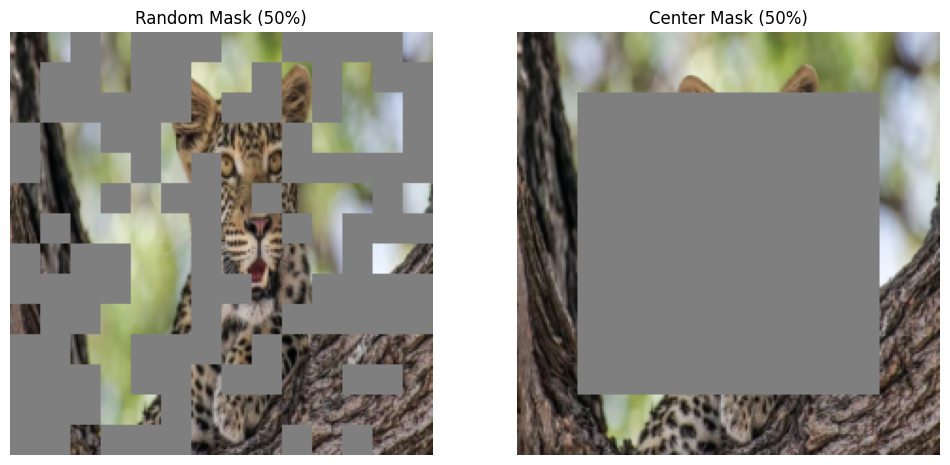

In [148]:
patch_size = 16
num_patches = 196
grid_size = 14
mask_frac = 0.5
seed = None

random_mask = get_random_patch_mask(grid_size, mask_frac, 42)
random_test = apply_patch_mask(imgs["pixel_values"], random_mask, patch_size, mask_frac)
random_test = random_test[0].permute(1, 2, 0).numpy()

center_mask =  get_center_patch_mask(grid_size, mask_frac)
center_test = apply_patch_mask(imgs["pixel_values"], center_mask, patch_size, mask_frac)
center_test = center_test[0].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.clip(random_test, 0, 1))
axes[0].set_title(f"Random Mask ({mask_frac*100:.0f}%)")
axes[0].axis("off")

axes[1].imshow(np.clip(center_test, 0, 1))
axes[1].set_title(f"Center Mask ({mask_frac*100:.0f}%)")
axes[1].axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

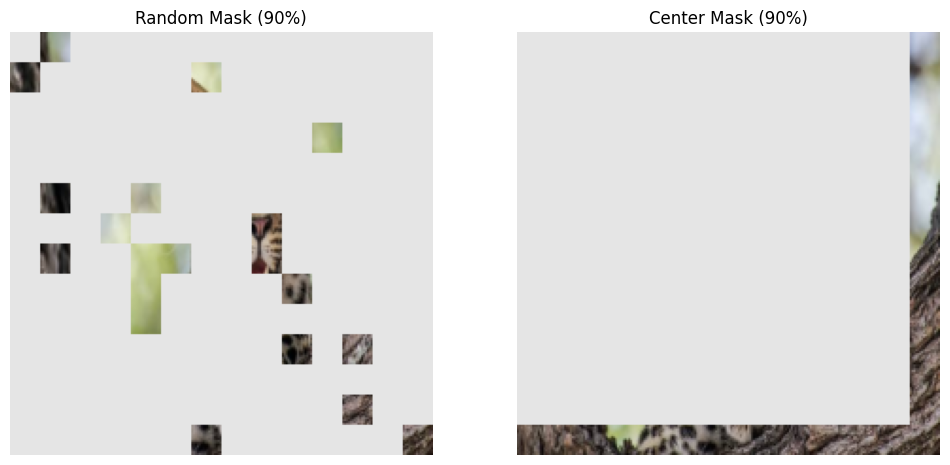

In [164]:
patch_size = 16
num_patches = 196
grid_size = 14
mask_frac = 0.9
seed = None

random_mask = get_random_patch_mask(grid_size, mask_frac, 42)
random_test = apply_patch_mask(imgs["pixel_values"], random_mask, patch_size, mask_frac)
random_test = random_test[0].permute(1, 2, 0).numpy()

center_mask =  get_center_patch_mask(grid_size, mask_frac)
center_test = apply_patch_mask(imgs["pixel_values"], center_mask, patch_size, mask_frac)
center_test = center_test[0].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.clip(random_test, 0, 1))
axes[0].set_title(f"Random Mask ({mask_frac*100:.0f}%)")
axes[0].axis("off")

axes[1].imshow(np.clip(center_test, 0, 1))
axes[1].set_title(f"Center Mask ({mask_frac*100:.0f}%)")
axes[1].axis("off")

In [162]:
fraction_list = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]

num_trials = 10
org_pixel_vals = inputs.pixel_values.to(DEVICE)

model.eval()

with torch.no_grad():
  orig_outputs = model(**inputs, output_attentions=True)
  orig_logits = orig_outputs.logits
  orig_probs = orig_logits.softmax(-1)

orig_top1 = orig_logits.argmax(-1)
print("Original predications:", orig_top1.tolist())

masking_res = []
for frac in fraction_list:

  random_consistency = []
  random_target_prob = []

  for trail in range(num_trials):

    seed = 42 + trail

    # random mask
    random_mask = get_random_patch_mask(grid_size, frac, seed)
    if trail == 0:
      random_mask_count = random_mask.sum().item()

    random_pixels = apply_patch_mask(org_pixel_vals, random_mask, patch_size, 0.0)
    with torch.no_grad():
      random_outputs = model(pixel_values=random_pixels)
      random_prob = random_outputs.logits.softmax(-1)

    random_pred = random_prob.argmax(dim=-1)

    consistency = (random_pred == orig_top1).float().mean().item()
    random_consistency.append(consistency)

    target_prob = random_prob.gather(1, orig_top1.unsqueeze(-1)).mean().item()
    random_target_prob.append(target_prob)

  center_mask =  get_center_patch_mask(grid_size,  frac)
  center_mask_count = center_mask.sum().item()

  if random_mask_count != center_mask_count:
    print(f"Warning: {frac*100:.0f}% masking -> ransom=:  {random_mask_count} center=: {center_mask_count}")

  #center masl
  center_pixels = apply_patch_mask(org_pixel_vals, center_mask, patch_size, 0.0)
  with torch.no_grad():
    center_outputs = model(pixel_values=center_pixels)
    center_prob = center_outputs.logits.softmax(-1)

  center_pred = center_prob.argmax(dim=-1)
  center_consistency = (center_pred == orig_top1).float().mean().item()

  center_target_prob = center_prob.gather(1, orig_top1.unsqueeze(-1)).mean().item()

  masking_res.append({
        "fraction": frac,
        "masked_patches": center_mask_count,
        "random_consistancy_mean": np.mean(random_consistency),
        "random_consistancy_std": np.std(random_consistency),
        "random_target_prob_mean": np.mean(random_target_prob),
        "random_target_prob_std": np.std(random_target_prob),
        "center_consistency": center_consistency,
        "center_target_prob": center_target_prob})


print("\n" + "=" * 100)
print(f"{'Mask %':>8} {'Patches':>8} {'Random Consistency':>24} {'Random Target Prob':>24} {'Center Consistency':>22} {'Center Target Prob':>22}")

for res in masking_res:
    print(
        f"{res['fraction'] * 100:7.0f}%"
        f" {res['masked_patches']:8.0f}"
        f" {res['random_consistancy_mean']:12.4f} ± {res['random_consistancy_std']:9.4f}"
        f" {res['random_target_prob_mean']:14.4f} ± {res['random_target_prob_std']:9.4f}"
        f" {res['center_consistency']:22.4f}"
        f" {res['center_target_prob']:22.4f}"
    )

print("\n" + "=" * 100)


Original predications: [288]

  Mask %  Patches       Random Consistency       Random Target Prob     Center Consistency     Center Target Prob
      0%        0       1.0000 ±    0.0000         0.9900 ±    0.0000                 1.0000                 0.9900
     10%       16       1.0000 ±    0.0000         0.9864 ±    0.0022                 1.0000                 0.9813
     25%       49       1.0000 ±    0.0000         0.9801 ±    0.0034                 1.0000                 0.9912
     50%      100       1.0000 ±    0.0000         0.9663 ±    0.0126                 1.0000                 0.9661
     75%      144       0.9000 ±    0.3000         0.6959 ±    0.2986                 1.0000                 0.8764
     90%      169       0.2000 ±    0.4000         0.0906 ±    0.1595                 1.0000                 0.8131



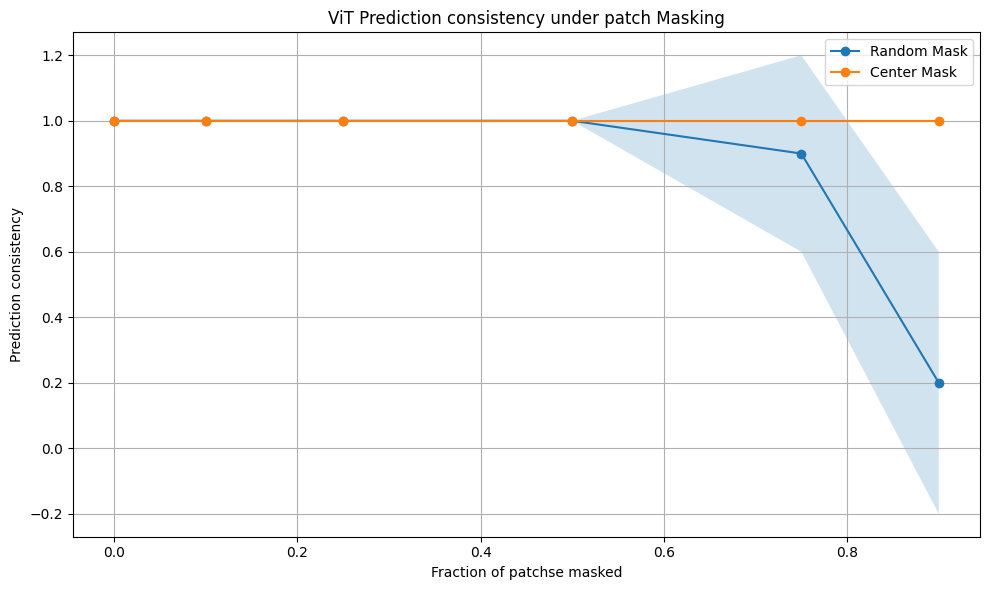

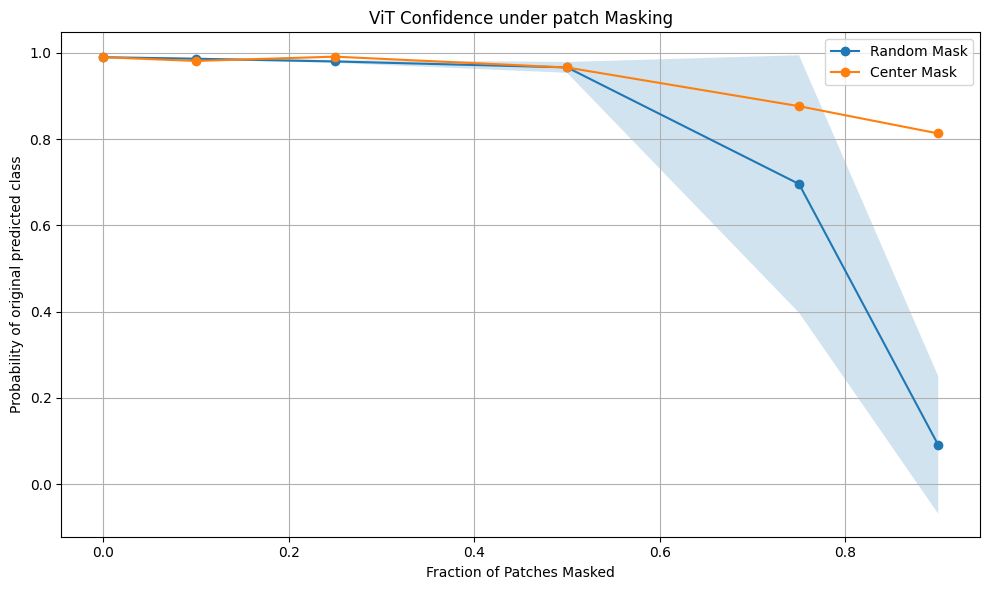

In [163]:

fractions              = [r["fraction"] for r in masking_res]
random_consistency     = [r["random_consistancy_mean"] for r in masking_res ]
random_consistency_std = [r["random_consistancy_std"] for r in masking_res]
center_consistency     = [r["center_consistency"]for r in masking_res]
random_target_prob     = [r["random_target_prob_mean"]for r in masking_res]
random_target_prob_std = [r["random_target_prob_std"]for r in masking_res]
center_target_prob     = [r["center_target_prob"]for r in masking_res]


plt.figure(figsize=(10, 6))
plt.plot(fractions, random_consistency, marker="o", label="Random Mask")
plt.fill_between(fractions, np.array(random_consistency)- np.array(random_consistency_std),
                            np.array(random_consistency) + np.array(random_consistency_std),alpha=0.2)
plt.plot(fractions, center_consistency, marker="o", label="Center Mask")
plt.xlabel("Fraction of patchse masked")
plt.ylabel("Prediction consistency")
plt.title("ViT Prediction consistency under patch Masking")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(fractions, random_target_prob ,marker="o" ,label="Random Mask")
plt.fill_between(fractions, np.array(random_target_prob) - np.array(random_target_prob_std),
                 np.array(random_target_prob)+ np.array(random_target_prob_std),alpha=0.2)
plt.plot(fractions, center_target_prob, marker="o", label="Center Mask")
plt.xlabel("Fraction of Patches Masked")
plt.ylabel("Probability of original predicted class")
plt.title("ViT Confidence under patch Masking")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Patch Masking and ViT Robustness

Two types of patch masking strategies were used to evalute ViT for robustness. Random Masking which randomly masks different patches of the image and structured Center Masking by masking the images' center via a continuos square region.

The original image, an image with leapord, the model correctly predict class 288 (leapord) with the probability of 0.99. To measure the model robustness two quantities are used. First, prediction consistency:

 $$C(f) = \frac{1}{N_{\text{eval}}} \sum_{i=1}^{N_{\text{eval}}} \mathbb{I}\left[ \hat{y}_i(f) = \hat{y}_i(0) \right]$$

 Variables:
 - $C(f)$: Empirical prediction consistency across evaluation samples at masking fraction $f \in [0, 1]$.$\hat{y}_i(0)$: Model top-1 predicted class on the unmasked image ($\text{fraction} = 0$).
 - $\hat{y}_i(f)$: Model top-1 predicted class on the perturbed/masked image $X_i(f)$.
 - $\mathbb{I}[\cdot]$: Indicator function returning $1$ if the condition is satisfied, and $0$ otherwise.
 - $N_{\text{eval}}$: Total number of evaluated images or trials.

Prediction consistency measures how often the model is able to predict the same classas the original class with the masked image. Secondly, measured the probability assigned to the original predicted class


$$P_{\text{orig}}(f) = \frac{1}{N_{\text{eval}}} \sum_{i=1}^{N_{\text{eval}}} p_i\left(\hat{y}_i(0) \mid X_i(f)\right)$$

Variables:
- $P_{\text{orig}}(f)$: Average confidence (predicted probability) assigned to the original top-1 class under masking fraction $f$.
- $p_i(c \mid X)$: Output softmax probability assigned to class $c$ given input image
- $X$.$X_i(f)$: $i$-th image perturbed by masking fraction $f$ of its spatial patches.

The results table above shows that with upto 50% random masking ViT is able to demonstrate high robustness. The original prediction remains unchnages in all 10 trials with the probability assigned to orginal class remain at 0.96. This robustness begins to decrease with consistency falling to 0.90 and at 90% masking only 20% of the trials retain the orginal prediction and original class probability declines to 0.091 indicating that the ViT tolerated substantial distributed information loss, but its representation started to degrade after very few image patches remain.

This ViT robustoness is becasue of the self attention mechnism of the transformer archtecture. The CLS representation is an aggeration of information across all the patches in the image

   $$\mathbf{h}_{\text{CLS}} = \sum_{j=0}^{N} \mathbf{A}_{0, j} \mathbf{V}_j \in \mathbb{R}^d$$

so the prediction is not entierly dependent on some patch, therefore randomly removing/masking some patches still leaves sufficient visual infomration for classification.

In the case of center masking, the model is astonisingly able to predict for all tested masking fractions and its confidence remained relatively high even at the 90% mask, in contrast to the random maksing. However the most probable cause specific to this image in test is that even with 90% masked image the remaining 10% still got enough CLS representation to classify the correct class with high probability. This also tell that for this image the random masking resulted in loss of some critical information acorss the image which resulted in degraded performance beyond 75% masking.

In [154]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/ATML/assignment_00/vae'
except ImportError:
    RUN_DIR = './vae'  # not on Colab

os.makedirs(RUN_DIR, exist_ok=True)
DATA_ROOT = f'{RUN_DIR}/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [155]:
cifar_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

SUBSET_TRAIN = 2000
SUBSET_TEST = 500

BATCH_SIZE = 32

train_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=cifar_transform, download=True, train=True)
test_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=cifar_transform, download=True, train=False)

gen = torch.Generator().manual_seed(42)
train_index =  torch.randperm(len(train_cifar_ds), generator=gen)[:SUBSET_TRAIN].tolist()
test_index =  torch.randperm(len(test_cifar_ds), generator=gen)[:SUBSET_TEST].tolist()

train_loader = DataLoader(torch.utils.data.Subset(train_cifar_ds, train_index), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(torch.utils.data.Subset(test_cifar_ds, test_index), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


print(f"Train Samples: {len(train_index)} | Test Samples: {len(test_index)}")


Train Samples: 2000 | Test Samples: 500


In [173]:
def extract_vitfeatures(model, loader, max_samples=None):
  model.eval()
  cls_feats, mean_feats, all_labels = [], [], []
  already_seen = 0

  with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Extracting the VIT features"):
      if max_samples is not None and already_seen >= max_samples:
        break

      imgs = imgs.to(DEVICE)
      last_hdn = model.vit(imgs).last_hidden_state

      cls_feats.append(last_hdn[:, 0, :].cpu())
      mean_feats.append(last_hdn[:, 1:, :].mean(dim=1).cpu())
      all_labels.append(labels)

      already_seen += len(labels)

    cls = torch.cat(cls_feats)
    mean = torch.cat(mean_feats)
    labels = torch.cat(all_labels)

  return cls, mean, labels


def train_for_probe(X_train, y_train, X_test, y_test, num_classes, num_epochs=10, lr=1e-3, batch_size=32, seed=42):
    probe_model = nn.Linear(X_train.shape[1], num_classes).to(DEVICE)
    optimizer = optim.Adam(probe_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
      probe_model.train()
      total_loss, correct, total = 0.0, 0, 0

      for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = probe_model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(-1) == y).sum().item()
        total += x.size(0)

      print(f" epcoh {epoch +1}/{num_epochs} | loss {total_loss/total:.4f} | train acc {100*correct/total:.2f}%")

    probe_model.eval()
    with torch.no_grad():
      test_acc = 100 * (probe_model(X_test.to(DEVICE)).argmax(1).cpu() == y_test).float().mean().item()

    return probe_model, test_acc

In [174]:

vit_features_train =  extract_vitfeatures(model, train_loader)
vit_features_test = extract_vitfeatures(model, test_loader)

Extracting the VIT features:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Extracting the VIT features: 100%|██████████| 16/16 [05:58<00:00, 22.43s/it]


In [175]:

train_cls, train_mean, train_labels = vit_features_train
test_cls, test_mean, test_labels = vit_features_test


print("Trainning linear probe on CLS tokens features ... ")

cls_probe, cls_test_acc = train_for_probe(train_cls, train_labels, test_cls, test_labels, 10)
print("\nTrainning linear probe on mean pooled patch token features ... ")

mean_probe, mean_test_acc = train_for_probe(train_mean, train_labels, test_mean, test_labels, 10)
print(f"\nCLS token probe: {cls_test_acc:.2f}% | Mean pool probe: {mean_test_acc:.2f}%")

Trainning linear probe on CLS tokens features ... 
 epcoh 1/10 | loss 0.5464 | train acc 87.55%
 epcoh 2/10 | loss 0.1285 | train acc 96.75%
 epcoh 3/10 | loss 0.0872 | train acc 97.95%
 epcoh 4/10 | loss 0.0650 | train acc 98.95%
 epcoh 5/10 | loss 0.0484 | train acc 99.50%
 epcoh 6/10 | loss 0.0359 | train acc 99.80%
 epcoh 7/10 | loss 0.0286 | train acc 99.85%
 epcoh 8/10 | loss 0.0230 | train acc 99.85%
 epcoh 9/10 | loss 0.0189 | train acc 99.95%
 epcoh 10/10 | loss 0.0155 | train acc 99.95%

Trainning linear probe on mean pooled patch token features ... 
 epcoh 1/10 | loss 0.6582 | train acc 87.40%
 epcoh 2/10 | loss 0.1608 | train acc 97.20%
 epcoh 3/10 | loss 0.1107 | train acc 98.25%
 epcoh 4/10 | loss 0.0828 | train acc 98.65%
 epcoh 5/10 | loss 0.0639 | train acc 99.10%
 epcoh 6/10 | loss 0.0496 | train acc 99.40%
 epcoh 7/10 | loss 0.0400 | train acc 99.75%
 epcoh 8/10 | loss 0.0320 | train acc 99.85%
 epcoh 9/10 | loss 0.0264 | train acc 100.00%
 epcoh 10/10 | loss 0.0223 

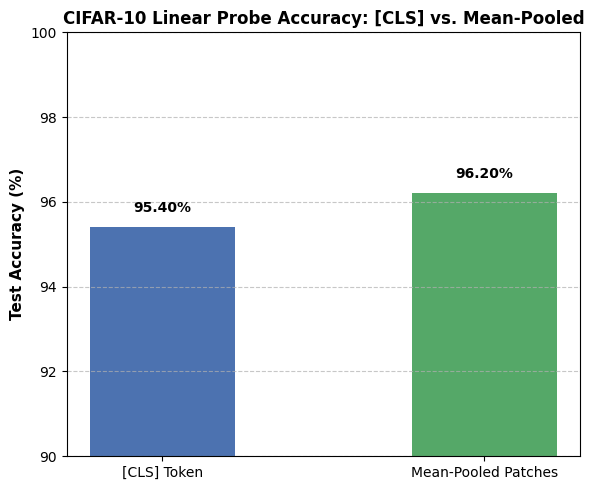

In [176]:
methods = ["[CLS] Token", "Mean-Pooled Patches"]
test_accuracies = [cls_test_acc, mean_test_acc]

plt.figure(figsize=(6, 5))
bars = plt.bar(methods, test_accuracies, color=["#4C72B0", "#55A868"], width=0.45)

plt.ylabel("Test Accuracy (%)", fontsize=11, fontweight="bold")
plt.title(
    "CIFAR-10 Linear Probe Accuracy: [CLS] vs. Mean-Pooled",
    fontsize=12,
    fontweight="bold",
)
plt.ylim(90, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.3,
        f"{yval:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# Linear Probing: [CLS] Token vs Mean-Pooled Patched Tokens

The final layers output is:

$$\mathbf{H} = [\mathbf{h}_{\text{CLS}}, \mathbf{z}_1, \mathbf{z}_2, \dots, \mathbf{z}_N] \in \mathbb{R}^{(N+1) \times d}$$

CLS Token pooling:

$$\mathbf{f}_{\text{CLS}} = \mathbf{h}_{\text{CLS}} = \sum_{j=0}^{N} \mathbf{A}_{0, j} \mathbf{V}_j \in \mathbb{R}^d$$

Mean-Pooled Patch Tokens takes an unweigths average across all 196 patches, while ignoring the special CLS token. It goal is to treat every patch equally which more likely captures the whole scene better thena relying on the CLS tokens learned attention.

$$\mathbf{f}_{\text{mean}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{z}_i \in \mathbb{R}^d$$

**The Linear Probe**

**The Linear Probe Formulation**

In linear probing, the pre-trained Vision Transformer backbone is kept completely **frozen** ($\nabla_{\theta_{\text{ViT}}} = 0$), acting purely as a static feature extractor. A single linear classification head parameterized by weight matrix $\mathbf{W} \in \mathbb{R}^{C \times d}$ and bias vector $\mathbf{b} \in \mathbb{R}^C$ (where $C = 10$ and $d = 768$) is trained on top of the extracted features $\mathbf{f} \in \{\mathbf{f}_{\text{CLS}}, \mathbf{f}_{\text{mean}}\}$.

For an input representation $\mathbf{f}^{(m)}$ and target class $y^{(m)}$, class logits $\mathbf{z} \in \mathbb{R}^C$ are computed as:
$$\mathbf{z} = \mathbf{W}\mathbf{f}^{(m)} + \mathbf{b}$$

The parameters $\mathbf{W}$ and $\mathbf{b}$ are optimized by minimizing the empirical multi-class cross-entropy loss over $M = 2000$ training samples:


$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{M} \sum_{m=1}^{M} \log \left( \frac{\exp\left(\mathbf{w}_{y^{(m)}}^\top \mathbf{f}^{(m)} + b_{y^{(m)}}\right)}{\sum_{c=1}^{C} \exp\left(\mathbf{w}_c^\top \mathbf{f}^{(m)} + b_c\right)} \right)$$



**Empirical Comparison & Results**


| Pooling Method | Test Accuracy (%) | Final Train Loss |
| :--- | :---: | :---: |
| **`[CLS]` Token Probe** | **95.40%** | 0.0155 |
| **Mean-Pooled Probe** | **96.20%** | 0.0223 |


The above listed emperical results shows that the Mean-pooled patch tokens (96.20%) silighly outperformed the CLS token (95.40%).

While the CLS token relies on learned attention weights ($\mathbf{A}_{0,:}$). Since the CLS token is an aggregated information via the learned softmwax weights, therefore, in deeper layers the attention distribution may become highly peaked on a few high contrast patches which can create an information bottleneck or over-focus on specific localized features.

Whereas in case of mean pooling, the uniform spatial aggregation is performed on every single patch, across all $14 \times 14 = 196$ patch tokens $\mathbf{f}_{\text{mean}} = \frac{1}{N}\sum_{i=1}^{196} \mathbf{z}_i$. It results preservation of the distributed global context and edge details that aid linear separability.

Why particularly relevant for low-resolution datasets (e.g., CIFAR-10)?

CIFAR-10 images are native 32×32 pixels upsampled to 224×224. At this resolution, fine-grained central object details are blurry, making distributed structural cues (such as overall outline, scene context, and background environment) critical for distinguishing classes like airplane vs. ship or frog vs. deer. Mean pooling preserves these distributed cues across all 196 tokens.

**Interaction with Pre-training Objectives**

**Supervised Pre-training (ImageNet-21k):** In case of supervised classification the loss is applied directly to the CLS token ($\mathcal{L}_{\text{sup}} = \ell_{\text{CE}}(\mathbf{W}_{\text{head}} \mathbf{h}_{\text{CLS}}, y)$). This results in forcing the self-attention heads to gather the class related features from the patches and route them to the CLS token, resulting in high linear separation for both the CLS and mean pooled token.

**Masked Autoencoding (MAE):**

Since in masked autoencoding model hides 75% of the image patchs and thentrains the network to predict the raw pixel values for those missing patches supervised by the Mean Squared Error.

$$\mathcal{L}_{\text{MAE}} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \|\hat{\mathbf{x}}_i - \mathbf{x}_i\|_2^2$$

This forces every individual patch token to learn more local textures, geometery and the semantics to reconstruct the pixels as the CLS token was never trained for summarizing the image. This result in limited information in CLS token. Whereas the averaging across all the patch tokens gather the rich local details allowing mean pooling to perform better for linear probing.

* **Self-Distillation (DINO):** DINO used the cross-entropy objective directly to align the student and teacher CLS token across the different image corps:

$$\mathcal{L}_{\text{DINO}} = -\sum \mathbf{p}_{\text{teacher}}(\mathbf{h}_{\text{CLS}}) \log \mathbf{p}_{\text{student}}(\mathbf{h}_{\text{CLS}})$$

Thus forcing the CLS token to capture high-level semantic abstractions and clear foreground masks.